In [1]:
import numpy as np
import pandas as pd

from scformer.utils import *
from scformer.model import *
from warnings import filterwarnings
import random
import os
import torch
import torch.cuda as cuda
from scipy import sparse
import scanpy as sc
import anndata as ad
from scipy.sparse import csr_matrix

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [2]:
# 加载表达矩阵
expression_matrix = pd.read_csv("data/mouse_retina/expression_matrix.csv", index_col=0)
expression_matrix_ = csr_matrix(expression_matrix)
expression_matrix_

<6275x9383 sparse matrix of type '<class 'numpy.int64'>'
	with 3571165 stored elements in Compressed Sparse Row format>

In [3]:
# 创建AnnData对象
adata = sc.AnnData(expression_matrix_.transpose())

# 添加基因和细胞的名称
adata.var_names = expression_matrix.index  # 基因名称
adata.obs_names = expression_matrix.columns  # 细胞名称

In [4]:
# 加载细胞元数据
cell_metadata = pd.read_csv("data/mouse_retina/cell_metadata.csv", index_col=0)

# 将元数据添加到AnnData对象中
adata.obs = cell_metadata
adata

AnnData object with n_obs × n_vars = 9383 × 6275
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype'

In [5]:
node_ids = np.load("data/mouse_retina/output/node_ids.npy")
node_ids

array([4924, 5093, 2172, ...,  738, 4270, 8127])

In [6]:
cell_emb = np.load("data/mouse_retina/output/cell_embedding.npy")
cell_emb

array([[ 5.098477  , -1.6833042 , -1.5023867 , ..., -1.772586  ,
        -1.7713952 , -1.7724147 ],
       [-1.5387826 ,  5.1258974 , -0.87280583, ..., -1.7726367 ,
        -1.7714183 , -1.7696931 ],
       [-0.7174731 , -0.26588857, -0.7355986 , ..., -1.7706381 ,
        -1.7713611 , -1.7701684 ],
       ...,
       [ 5.1450453 , -1.5255172 , -1.4830836 , ..., -1.7724339 ,
        -1.7713993 , -1.772768  ],
       [ 5.102787  , -1.3762238 , -1.6422731 , ..., -1.7728428 ,
        -1.7714585 , -1.7731816 ],
       [ 5.142193  , -1.6404128 , -1.5706179 , ..., -1.772901  ,
        -1.7714374 , -1.7710912 ]], dtype=float32)

In [7]:
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_

,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,99,100,101,102,103
4924,5.098477,-1.683304,-1.502387,-1.543134,-1.678101,-1.730204,-1.870227,-1.741599,-1.423232,-1.563031,...,-1.771791,-1.769379,-1.782512,-1.776426,-1.771639,-1.772351,-1.770549,-1.772586,-1.771395,-1.772415
5093,-1.538783,5.125897,-0.872806,-1.574683,-1.471837,-1.511978,-1.578917,-1.431032,-1.421816,-1.471130,...,-1.778713,-1.772232,-1.774468,-1.748569,-1.771684,-1.775060,-1.770978,-1.772637,-1.771418,-1.769693
2172,-0.717473,-0.265889,-0.735599,-1.342316,-1.309652,-1.246705,-1.241673,-1.025637,-1.468457,-1.227739,...,-1.771602,-1.771237,-1.770531,-1.778335,-1.771309,-1.769242,-1.768885,-1.770638,-1.771361,-1.770168
3505,5.141352,-1.716064,-1.675785,-1.629622,-1.528571,-1.651147,-1.673416,-1.631355,-1.509412,-1.607977,...,-1.773558,-1.772936,-1.778370,-1.781607,-1.771882,-1.772642,-1.770030,-1.771429,-1.771425,-1.772851
2577,5.127234,-1.565827,-1.539469,-1.689880,-1.656082,-1.671160,-1.656886,-1.662517,-1.481600,-1.642192,...,-1.773510,-1.770664,-1.777374,-1.772770,-1.772433,-1.770775,-1.772981,-1.770856,-1.771436,-1.773191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3098,-0.860178,-0.670968,-0.996429,-0.982388,-1.325969,-1.077242,5.192299,-1.116940,-1.271418,-1.580119,...,-1.771136,-1.770010,-1.768984,-1.779894,-1.771454,-1.771124,-1.772678,-1.770965,-1.771307,-1.770809
1044,-1.394300,5.091908,-0.871276,-1.561243,-1.388877,-1.651167,-1.491103,-1.588787,-1.421540,-1.557897,...,-1.775273,-1.771762,-1.775745,-1.807961,-1.770997,-1.775515,-1.774884,-1.770525,-1.771286,-1.772963
738,5.145045,-1.525517,-1.483084,-1.730500,-1.832019,-1.620810,-1.605438,-1.659582,-1.542736,-1.525705,...,-1.770699,-1.770183,-1.786020,-1.785045,-1.771939,-1.772592,-1.770930,-1.772434,-1.771399,-1.772768
4270,5.102787,-1.376224,-1.642273,-1.614496,-1.766259,-1.742828,-1.886896,-1.627544,-1.570037,-1.613274,...,-1.770263,-1.772989,-1.770471,-1.778503,-1.772204,-1.773130,-1.770765,-1.772843,-1.771459,-1.773182


In [8]:
# 按照索引排序
cell_emb_sorted = cell_emb_.sort_index()


In [9]:
pred = np.load('data/mouse_retina/output/pred.npy')
pred_ = pd.DataFrame(pred, index=node_ids)
pred_sorted = pred_.sort_index()
pred_sorted

,0
0,9
1,7
2,0
3,0
4,7
...,...
9378,17
9379,0
9380,0
9381,1


In [10]:
adata

AnnData object with n_obs × n_vars = 9383 × 6275
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype'

In [11]:
cell_emb_sorted.shape

(9383, 104)

In [12]:
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')

In [13]:
adata.obsm['cell_emb'] = cell_emb_sorted.values

In [14]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

adjusted_rand_score(adata.obs['celltype'], adata.obs['pre'])
normalized_mutual_info_score(adata.obs['celltype'], adata.obs['pre'])

0.7306381405022443

In [15]:
adata.var_names_make_unique()
sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep='cell_emb')
sc.tl.umap(adata)

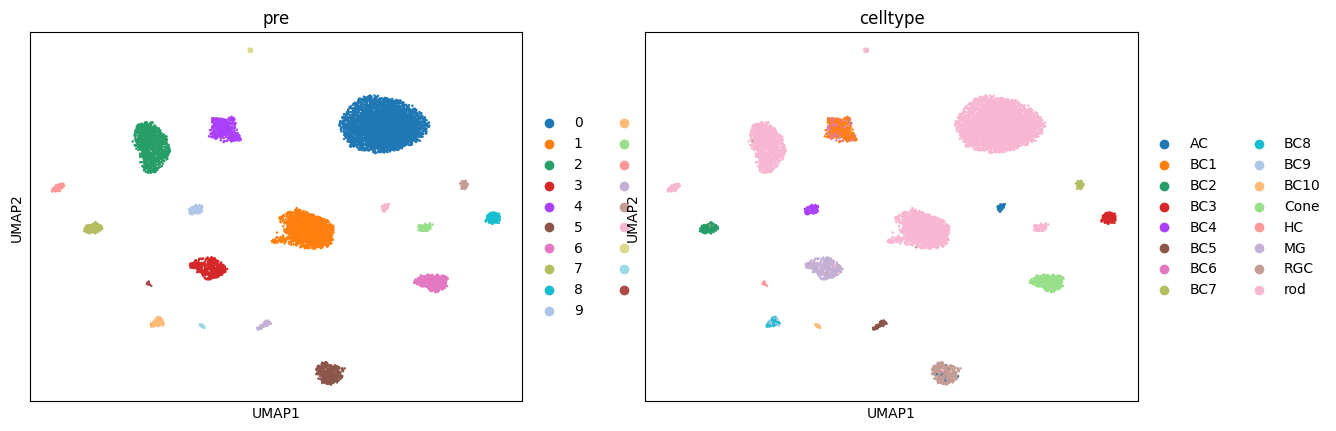

In [16]:
sc.pl.umap(adata, color=['pre', 'celltype'], show=True)

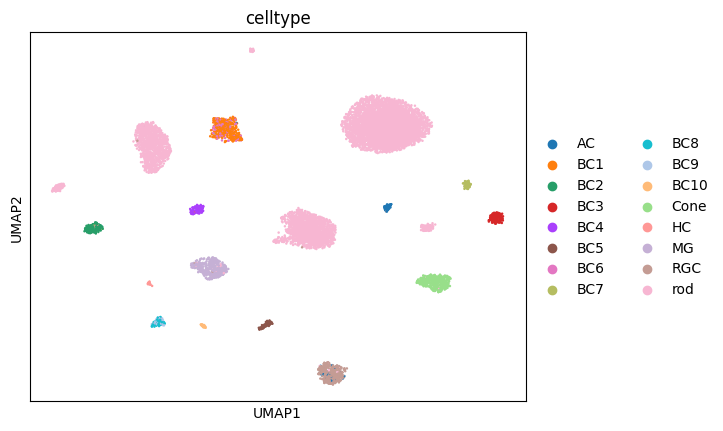

In [17]:
sc.pl.umap(adata, color=['celltype'], show=True)